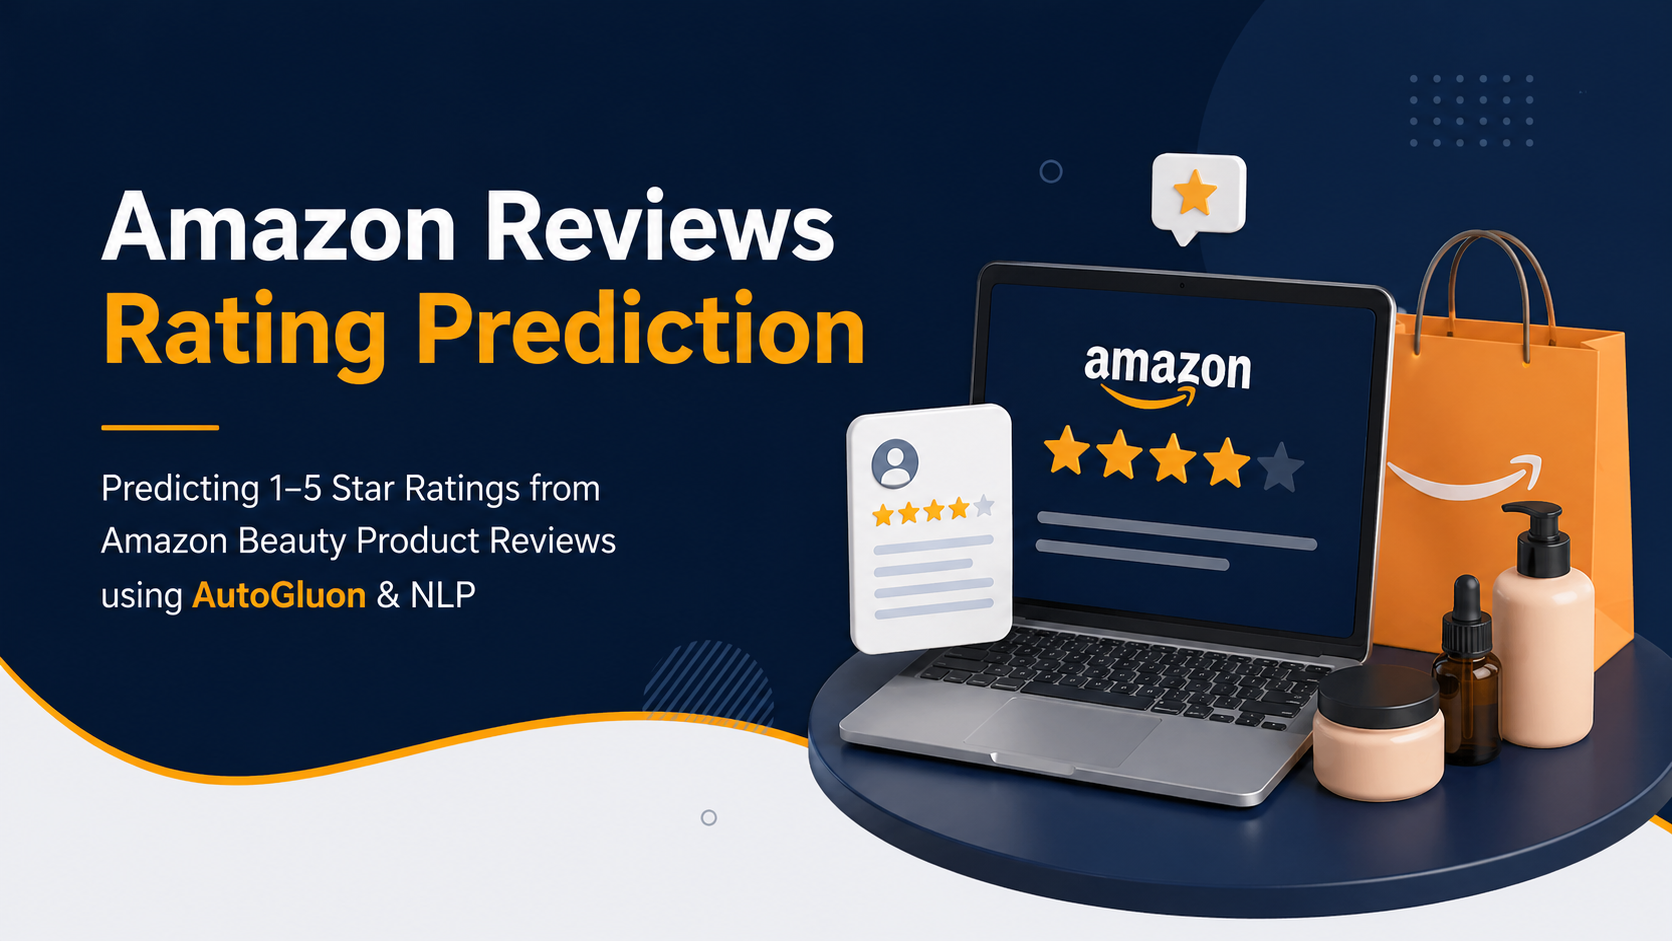

# Amazon Reviews Rating Prediction
 ## Project Description

This project builds a Machine Learning model that predicts the star rating (1–5) a customer would give to an Amazon Beauty product based on their written review and product information. The model learns patterns from real Amazon reviews to understand the relationship between review content and customer satisfaction levels.
We use the Amazon Reviews 2023 dataset (All_Beauty category) collected by McAuley Lab at UCSD, which contains hundreds of thousands of authentic customer reviews. The model is built using AutoGluon, an automated machine learning framework that trains and ensembles multiple models (LightGBM, XGBoost, Neural Networks, etc.) to find the best performing one. Finally, we deploy the trained model through a Gradio web interface that anyone can use to predict ratings from new reviews in real time.

 ## Project Goal

The main goal is to develop an accurate predictive model that can estimate a customer's rating from their review text, which has several real-world applications:

Auto-suggesting ratings for users who write reviews but forget to rate
Detecting inconsistent reviews (e.g., a 5-star rating with negative text) to flag potential fake or spam reviews
Ranking helpful reviews by combining predicted sentiment with confidence scores
Understanding customer satisfaction at scale without manually reading every review


 ## ML Task

Multi-class Classification with 5 ordered classes (1, 2, 3, 4, 5 stars).
We also evaluate using ordinal metrics (MAE, RMSE, off-by-N accuracy) since the rating classes have a natural order.

 ## Dataset

PropertyValueSourceAmazon Reviews 2023 - McAuley Lab, UCSDCategoryAll_BeautySample size30,000 reviewsTime range1996 – 2023Features usedReview text, title, helpful votes, verified purchase, product price, product avg rating, store, timestamp, and moreTarget variablerating (1 to 5 stars)

 ## Tools & Technologies


Python 3 — programming language

AutoGluon — automated machine learning framework

Pandas / NumPy — data manipulation

Matplotlib / Seaborn — data visualization

Scikit-learn — evaluation metrics & data splitting

Gradio — interactive web interface for the deployed model

Google Colab — cloud-based notebook with free GPU acceleration


## Notebook Workflow


Setup & Library Installation — Install AutoGluon, Gradio, and dependencies

Data Loading — Download and load reviews + product metadata

Exploratory Data Analysis (EDA) — Visualize rating distribution, text lengths, verified purchases, and helpful votes

Data Cleaning — Handle missing values and merge reviews with product info

Feature Engineering — Create 20+ features from text, time, behavior, and product data

Train/Test Split — Stratified 80/20 split to preserve class distribution

Model Training — Train multiple models with AutoGluon and ensemble the best

Model Evaluation — Measure Accuracy, F1-score, MAE, RMSE, and confusion matrix

Feature Importance — Identify which features drive predictions the most

Deployment — Launch a Gradio web app to make predictions on new reviews


 ## Success Criteria


Accuracy ≥ 65% — clearly beats random / majority-class baseline

MAE ≤ 0.7 stars — predictions are on average within half a star of the truth

Off-by-1 accuracy ≥ 90% — almost all predictions are within 1 star of the actual rating

## 1) Install library



In [ ]:

!pip install -q autogluon.tabular[all]
!pip install -q gradio

print('done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.9/98.9 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.2/97.2 MB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 112.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 15.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# import all library
import os
import json
import gzip
import urllib.request
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# التأكد من وجود GPU
import torch
if torch.cuda.is_available():
    print(f'  GPU is available: {torch.cuda.get_device_name(0)}')
else:
    print('GPU is not available - using CPU (slower)')
    print('   Go to: Runtime → Change runtime type → T4 GPU')

print('\n All libraries imported successfully ')

  GPU is available: Tesla T4

 All libraries imported successfully 


## 2) Load the data : Amazon Reviews 2023

In [ ]:
# إنشاء مجلد البيانات
DATA_DIR = '/content/data'
MODEL_DIR = '/content/models'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# روابط البيانات
REVIEW_URL = 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/review_categories/All_Beauty.jsonl.gz'
META_URL = 'https://mcauleylab.ucsd.edu/public_datasets/data/amazon_2023/raw/meta_categories/meta_All_Beauty.jsonl.gz'

REVIEW_FILE = os.path.join(DATA_DIR, 'All_Beauty.jsonl.gz')
META_FILE = os.path.join(DATA_DIR, 'meta_All_Beauty.jsonl.gz')

def download_file(url, filepath):
    if not os.path.exists(filepath):
        print(f'load {os.path.basename(filepath)}...')
        urllib.request.urlretrieve(url, filepath)
        size_mb = os.path.getsize(filepath) / (1024 * 1024)
        print(f'done({size_mb:.1f} MB)')
    else:
        print(f'✓ {os.path.basename(filepath)} موجود مسبقاً')

download_file(REVIEW_URL, REVIEW_FILE)
download_file(META_URL, META_FILE)

load All_Beauty.jsonl.gz...
done(90.1 MB)
load meta_All_Beauty.jsonl.gz...
done(38.0 MB)


In [ ]:
# Load data into memory
SAMPLE_SIZE = 30000

def load_jsonl_gz(filepath, max_records=None):
    """Load compressed JSONL file"""
    records = []
    with gzip.open(filepath, 'rt', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if max_records and i >= max_records:
                break
            records.append(json.loads(line.strip()))
    return records

print(' Loading reviews...')
reviews = load_jsonl_gz(REVIEW_FILE, max_records=SAMPLE_SIZE)
df_reviews = pd.DataFrame(reviews)
print(f' {len(df_reviews):,} reviews loaded')

print('\n Loading product metadata...')
meta = load_jsonl_gz(META_FILE)
df_meta = pd.DataFrame(meta)
print(f' {len(df_meta):,} products loaded')

 Loading reviews...
 30,000 reviews loaded

 Loading product metadata...
 112,590 products loaded


In [ ]:
print('=== Sample of Reviews ===')
df_reviews.head(3)

=== Sample of Reviews ===


,rating,title,text,images,asin,parent_asin,user_id,timestamp,helpful_vote,verified_purchase
0,5.0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,[],B00YQ6X8EO,B00YQ6X8EO,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588687728923,0,True
1,4.0,Works great but smells a little weird.,"This product does what I need it to do, I just...",[],B081TJ8YS3,B081TJ8YS3,AGKHLEW2SOWHNMFQIJGBECAF7INQ,1588615855070,1,True
2,5.0,Yes!,"Smells good, feels great!",[],B07PNNCSP9,B097R46CSY,AE74DYR3QUGVPZJ3P7RFWBGIX7XQ,1589665266052,2,True


In [ ]:
print('=== Sample of Product Data ===')
df_meta.head(3)

=== Sample of Product Data ===


,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together
0,All Beauty,"Howard LC0008 Leather Conditioner, 8-Ounce (4-...",4.8,10,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Howard Products,[],{'Package Dimensions': '7.1 x 5.5 x 3 inches; ...,B01CUPMQZE,None
1,All Beauty,Yes to Tomatoes Detoxifying Charcoal Cleanser ...,4.5,3,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Yes To,[],"{'Item Form': 'Powder', 'Skin Type': 'Acne Pro...",B076WQZGPM,None
2,All Beauty,Eye Patch Black Adult with Tie Band (6 Per Pack),4.4,26,[],[],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Levine Health Products,[],{'Manufacturer': 'Levine Health Products'},B000B658RI,None


## 3) EDA




In [ ]:
# Basic statistics
print(f' Total reviews:      {len(df_reviews):,}')
print(f' Unique products:    {df_reviews["parent_asin"].nunique():,}')
print(f' Unique users:       {df_reviews["user_id"].nunique():,}')

ts_min = pd.to_datetime(df_reviews['timestamp'], unit='ms').min()
ts_max = pd.to_datetime(df_reviews['timestamp'], unit='ms').max()
print(f' Time range:         {ts_min.date()} → {ts_max.date()}')

print(f'\n Missing values:')
print(df_reviews.isnull().sum())

 Total reviews:      30,000
 Unique products:    16,756
 Unique users:       22,896
 Time range:         2002-12-10 → 2023-03-20

 Missing values:
rating               0
title                0
text                 0
images               0
asin                 0
parent_asin          0
user_id              0
timestamp            0
helpful_vote         0
verified_purchase    0
dtype: int64


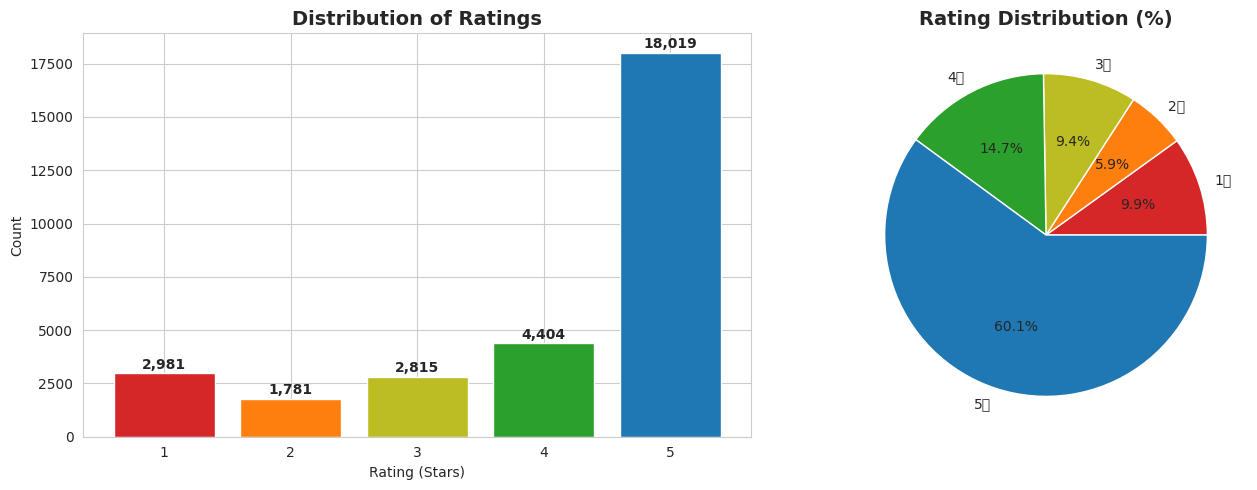


 Class distribution:
rating
1.0     2981
2.0     1781
3.0     2815
4.0     4404
5.0    18019
Name: count, dtype: int64

Most frequent rating: 5.0 stars (60.1%)


In [ ]:
# Distribution of the target variable (ratings)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rating_counts = df_reviews['rating'].value_counts().sort_index()
colors = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

# Bar chart for rating distribution
axes[0].bar(rating_counts.index, rating_counts.values, color=colors)
axes[0].set_title('Distribution of Ratings', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Rating (Stars)')
axes[0].set_ylabel('Count')

for i, v in enumerate(rating_counts.values):
    axes[0].text(rating_counts.index[i], v + 200, f'{v:,}', ha='center', fontweight='bold')

# Pie chart for percentage distribution
axes[1].pie(
    rating_counts.values,
    labels=[f'{int(r)}⭐' for r in rating_counts.index],
    autopct='%1.1f%%',
    colors=colors
)
axes[1].set_title('Rating Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n Class distribution:')
print(rating_counts)

print(f'\nMost frequent rating: {rating_counts.idxmax()} stars '
      f'({rating_counts.max() / len(df_reviews) * 100:.1f}%)')

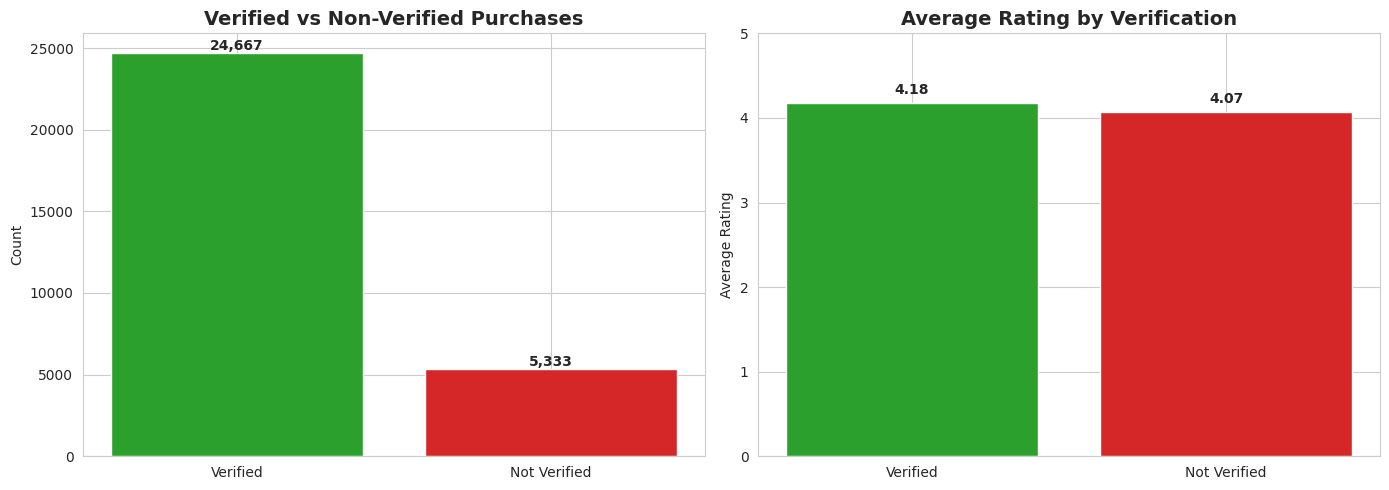

In [ ]:
# تحليل الشراء الموثق
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vp_counts = df_reviews['verified_purchase'].value_counts()
axes[0].bar(['Verified', 'Not Verified'], vp_counts.values, color=['#2ca02c', '#d62728'])
axes[0].set_title('Verified vs Non-Verified Purchases', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vp_counts.values):
    axes[0].text(i, v + 200, f'{v:,}', ha='center', fontweight='bold')

vp_rating = df_reviews.groupby('verified_purchase')['rating'].mean()
axes[1].bar(['Verified', 'Not Verified'], vp_rating.values, color=['#2ca02c', '#d62728'])
axes[1].set_title('Average Rating by Verification', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Average Rating')
axes[1].set_ylim(0, 5)
for i, v in enumerate(vp_rating.values):
    axes[1].text(i, v + 0.1, f'{v:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

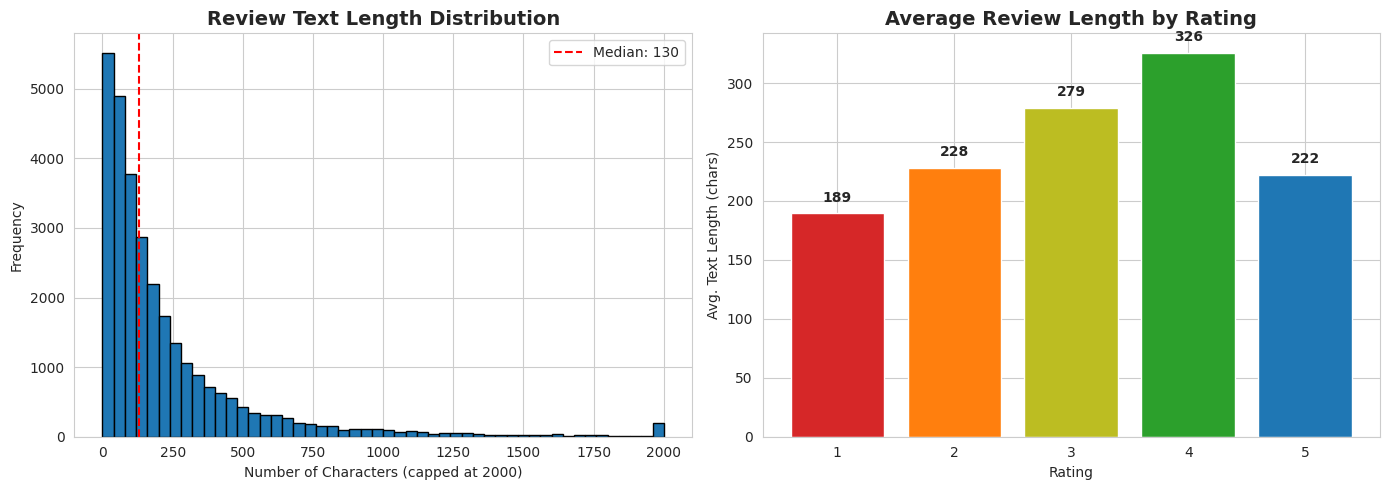


 Text Length Statistics
count    30000.000000
mean       239.865367
std        346.458297
min          0.000000
25%         54.000000
50%        130.000000
75%        285.000000
max      10205.000000
Name: text_length, dtype: float64


In [ ]:
# تحليل طول النص
df_reviews['text_length'] = df_reviews['text'].fillna('').str.len()
df_reviews['word_count'] = df_reviews['text'].fillna('').str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_reviews['text_length'].clip(upper=2000), bins=50, color='#1f77b4', edgecolor='black')
axes[0].set_title('Review Text Length Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Characters (capped at 2000)')
axes[0].set_ylabel('Frequency')
median_len = df_reviews['text_length'].median()
axes[0].axvline(median_len, color='red', linestyle='--', label=f'Median: {median_len:.0f}')
axes[0].legend()

avg_len_by_rating = df_reviews.groupby('rating')['text_length'].mean()
axes[1].bar(avg_len_by_rating.index, avg_len_by_rating.values, color=colors)
axes[1].set_title('Average Review Length by Rating', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Rating')
axes[1].set_ylabel('Avg. Text Length (chars)')
for i, v in enumerate(avg_len_by_rating.values):
    axes[1].text(avg_len_by_rating.index[i], v + 10, f'{v:.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

print('\n Text Length Statistics')
print(df_reviews['text_length'].describe())

 إحصائيات الأصوات المفيدة:
count    30000.000000
mean         0.970133
std          5.155016
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max        430.000000
Name: helpful_vote, dtype: float64


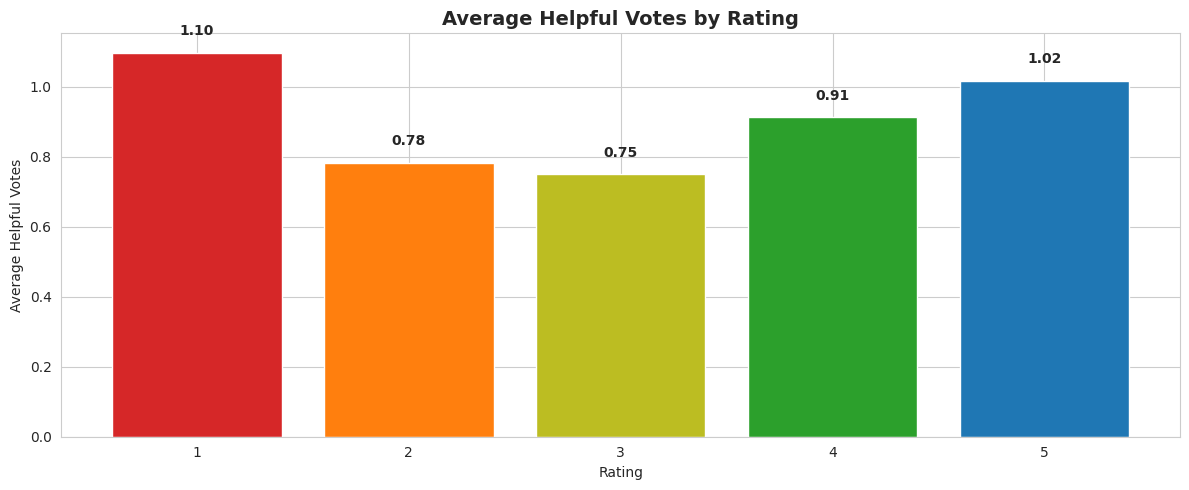

In [ ]:
# تحليل الأصوات المفيدة
print(f' إحصائيات الأصوات المفيدة:')
print(df_reviews['helpful_vote'].describe())

fig, ax = plt.subplots(figsize=(12, 5))
helpful_by_rating = df_reviews.groupby('rating')['helpful_vote'].mean()
ax.bar(helpful_by_rating.index, helpful_by_rating.values, color=colors)
ax.set_title('Average Helpful Votes by Rating', fontsize=14, fontweight='bold')
ax.set_xlabel('Rating')
ax.set_ylabel('Average Helpful Votes')
for i, v in enumerate(helpful_by_rating.values):
    ax.text(helpful_by_rating.index[i], v + 0.05, f'{v:.2f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

## 4) Data cleanimg

In [ ]:
# Clean reviews
print(f'Before cleaning: {len(df_reviews):,} reviews')

df_reviews = df_reviews.dropna(subset=['rating', 'text'])
df_reviews = df_reviews[df_reviews['text'].str.strip() != '']
df_reviews['rating'] = df_reviews['rating'].astype(int)
df_reviews['title'] = df_reviews['title'].fillna('')

print(f'After cleaning:  {len(df_reviews):,} reviews')

Before cleaning: 30,000 reviews
After cleaning:  29,996 reviews


In [ ]:
# Clean product data
meta_cols = ['parent_asin', 'main_category', 'title', 'average_rating',
             'rating_number', 'price', 'store']

df_meta_clean = df_meta[meta_cols].copy()

df_meta_clean.columns = ['parent_asin', 'product_category', 'product_title',
                         'product_avg_rating', 'product_rating_count',
                         'product_price', 'product_store']

df_meta_clean['product_price'] = pd.to_numeric(df_meta_clean['product_price'], errors='coerce')

print(f' Cleaned data: {len(df_meta_clean):,} products')
print(f'\nMissing values:')
print(df_meta_clean.isnull().sum())

 Cleaned data: 112,590 products

Missing values:
parent_asin                 0
product_category            0
product_title               0
product_avg_rating          0
product_rating_count        0
product_price           94886
product_store           11331
dtype: int64


In [ ]:
# Merge reviews with product data
df = df_reviews.merge(df_meta_clean, on='parent_asin', how='left')

print(f' Merged dataset: {len(df):,} rows × {df.shape[1]} columns')
print(f'\nColumns: {list(df.columns)}')

 Merged dataset: 29,996 rows × 18 columns

Columns: ['rating', 'title', 'text', 'images', 'asin', 'parent_asin', 'user_id', 'timestamp', 'helpful_vote', 'verified_purchase', 'text_length', 'word_count', 'product_category', 'product_title', 'product_avg_rating', 'product_rating_count', 'product_price', 'product_store']


## 5) Feature Engineering

In [ ]:
# === Text features ===

df['text_length'] = df['text'].str.len()
df['title_length'] = df['title'].str.len()
df['word_count'] = df['text'].str.split().str.len()
df['exclamation_count'] = df['text'].str.count('!')
df['question_count'] = df['text'].str.count(r'\?')

df['uppercase_ratio'] = df['text'].apply(
    lambda x: sum(1 for c in x if c.isupper()) / max(len(x), 1)
)

# Positive and negative words
POSITIVE_WORDS = ['love', 'great', 'excellent', 'amazing', 'perfect',
                  'best', 'wonderful', 'awesome', 'fantastic', 'recommend']

NEGATIVE_WORDS = ['bad', 'terrible', 'awful', 'worst', 'hate',
                  'horrible', 'disappointing', 'waste', 'broken', 'poor']

def count_words(text, word_list):
    text_lower = text.lower()
    return sum(text_lower.count(w) for w in word_list)

df['positive_word_count'] = df['text'].apply(lambda x: count_words(x, POSITIVE_WORDS))
df['negative_word_count'] = df['text'].apply(lambda x: count_words(x, NEGATIVE_WORDS))

print(' Text features created successfully')

 Text features created successfully


In [ ]:
# === Time-based features ===

df['datetime'] = pd.to_datetime(df['timestamp'], unit='ms')
df['review_year'] = df['datetime'].dt.year
df['review_month'] = df['datetime'].dt.month
df['review_dayofweek'] = df['datetime'].dt.dayofweek
df['review_hour'] = df['datetime'].dt.hour

print(' Time-based features created successfully')

 Time-based features created successfully


In [ ]:
# === Product and behavioral features ===

df['product_avg_rating'] = df['product_avg_rating'].fillna(df['product_avg_rating'].median())
df['product_rating_count'] = df['product_rating_count'].fillna(0)
df['product_price'] = df['product_price'].fillna(df['product_price'].median())
df['product_store'] = df['product_store'].fillna('Unknown')
df['product_title'] = df['product_title'].fillna('')

df['product_rating_count_log'] = np.log1p(df['product_rating_count'])
df['product_price_log'] = np.log1p(df['product_price'])

df['verified_purchase_int'] = df['verified_purchase'].astype(int)

df['has_image'] = df['images'].apply(
    lambda x: 1 if isinstance(x, list) and len(x) > 0 else 0
)

print(' Product and behavioral features created successfully')

 Product and behavioral features created successfully


In [ ]:
# Select final features

FEATURE_COLS = [
    'title', 'text',
    'text_length', 'title_length', 'word_count',
    'exclamation_count', 'question_count', 'uppercase_ratio',
    'positive_word_count', 'negative_word_count',
    'review_year', 'review_month', 'review_dayofweek', 'review_hour',
    'verified_purchase_int', 'helpful_vote', 'has_image',
    'product_avg_rating', 'product_rating_count_log', 'product_price_log', 'product_store',
]

TARGET_COL = 'rating'

df_model = df[FEATURE_COLS + [TARGET_COL]].copy()

print(f' Final dataset shape: {df_model.shape}')

df_model.head()

 Final dataset shape: (29996, 22)


,title,text,text_length,title_length,word_count,exclamation_count,question_count,uppercase_ratio,positive_word_count,negative_word_count,...,review_dayofweek,review_hour,verified_purchase_int,helpful_vote,has_image,product_avg_rating,product_rating_count_log,product_price_log,product_store,rating
0,Such a lovely scent but not overpowering.,This spray is really nice. It smells really go...,300,41,61,1,0,0.026667,0,0,...,1,14,1,0,0,4.3,5.953243,2.772589,HERBIVORE,5
1,Works great but smells a little weird.,"This product does what I need it to do, I just...",235,38,47,0,0,0.025532,0,0,...,0,18,1,1,0,4.0,4.043051,2.772589,Two Goats Apothecary,4
2,Yes!,"Smells good, feels great!",25,4,4,1,0,0.040000,1,0,...,5,21,1,2,0,4.4,6.551080,3.134624,New Road Beauty,5
3,Synthetic feeling,Felt synthetic,14,17,2,0,0,0.071429,0,0,...,4,18,1,0,0,1.0,0.693147,2.772589,muaowig,1
4,A+,Love it,7,2,2,0,0,0.142857,1,0,...,2,10,1,0,0,3.5,3.044522,2.772589,Yinhua,5


## 6) Data Splitting

In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model[TARGET_COL],
    random_state=RANDOM_SEED
)

print(f' Training data: {len(train_df):,} rows')
print(f' Test data:     {len(test_df):,} rows')

print(f'\nRating distribution in training set:')
print(train_df[TARGET_COL].value_counts(normalize=True).sort_index().round(3))

 Training data: 23,996 rows
 Test data:     6,000 rows

Rating distribution in training set:
rating
1    0.099
2    0.059
3    0.094
4    0.147
5    0.601
Name: proportion, dtype: float64


## 7) Model Training with AutoGluon



In [ ]:
from autogluon.tabular import TabularPredictor

MODEL_PATH = os.path.join(MODEL_DIR, 'autogluon_rating_predictor')

predictor = TabularPredictor(
    label=TARGET_COL,
    path=MODEL_PATH,
    problem_type='multiclass',
    eval_metric='accuracy'
)

predictor.fit(
    train_data=train_df,
    presets='medium_quality',
    time_limit=600,
    verbosity=2
)

print('\n Training completed!')

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.13
Operating System:   Linux
Platform Machine:   x86_64
Platform Version:   #1 SMP Mon Feb  2 12:27:57 UTC 2026
CPU Count:          2
Pytorch Version:    2.6.0+cu124
CUDA Version:       12.4
GPU Memory:         GPU 0: 14.56/14.56 GB
Total GPU Memory:   Free: 14.56 GB, Allocated: 0.00 GB, Total: 14.56 GB
GPU Count:          1
Memory Avail:       7.89 GB / 12.67 GB (62.3%)
Disk Space Avail:   66.05 GB / 118.86 GB (55.6%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 600s
AutoGluon will save models to "/content/models/autogluon_rating_predictor"
Train Data Rows:    23996
Train Data Columns: 21
Label Column:       rating
Problem Type:       multiclass
Preprocessing data ...
Train Data Class Count: 5
Using Feature Generators to preprocess the data ...
Fitting AutoML


 Training completed!


In [ ]:
# Model leaderboard
leaderboard = predictor.leaderboard(test_df, silent=True)

print(' Model leaderboard:')
leaderboard

 Model leaderboard:


,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,LightGBM,0.742167,0.730000,accuracy,3.028005,1.078612,88.325674,3.028005,1.078612,88.325674,1,True,3
1,LightGBMXT,0.742000,0.740417,accuracy,2.345312,1.292657,73.441374,2.345312,1.292657,73.441374,1,True,2
2,WeightedEnsemble_L2,0.742000,0.742500,accuracy,2.848589,2.584135,227.151282,0.003873,0.001047,0.133133,2,True,7
3,CatBoost,0.692667,0.687500,accuracy,0.383103,1.227753,116.341066,0.383103,1.227753,116.341066,1,True,6
4,RandomForestGini,0.681833,0.674583,accuracy,2.151318,0.463227,136.381144,2.151318,0.463227,136.381144,1,True,4
5,RandomForestEntr,0.678167,0.672917,accuracy,1.465231,0.358904,112.197810,1.465231,0.358904,112.197810,1,True,5
6,NeuralNetFastAI,0.601833,0.606250,accuracy,0.116301,0.062678,37.235710,0.116301,0.062678,37.235710,1,True,1


## 8) Model Evaluation

In [ ]:
y_pred = predictor.predict(test_df.drop(columns=[TARGET_COL]))
y_true = test_df[TARGET_COL]
y_pred_proba = predictor.predict_proba(test_df.drop(columns=[TARGET_COL]))

print(f'Number of predictions: {y_pred.shape}')
print(f'Sample predictions: {y_pred.head().tolist()}')
print(f'True values:        {y_true.head().tolist()}')

Number of predictions: (6000,)
Sample predictions: [5, 4, 5, 5, 5]
True values:        [5, 5, 5, 5, 4]


In [ ]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    mean_absolute_error, mean_squared_error, f1_score
)

acc = accuracy_score(y_true, y_pred)
f1_macro = f1_score(y_true, y_pred, average='macro')
f1_weighted = f1_score(y_true, y_pred, average='weighted')
mae = mean_absolute_error(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print('=' * 50)
print(' Model Performance Metrics')
print('=' * 50)
print(f'Accuracy:           {acc:.4f}  ({acc*100:.2f}%)')
print(f'F1 (macro):         {f1_macro:.4f}')
print(f'F1 (weighted):      {f1_weighted:.4f}')
print(f'MAE:                {mae:.4f}  (average error in stars)')
print(f'RMSE:               {rmse:.4f}')
print('=' * 50)

 Model Performance Metrics
Accuracy:           0.7420  (74.20%)
F1 (macro):         0.5462
F1 (weighted):      0.7153
MAE:                0.3988  (average error in stars)
RMSE:               0.9071


In [ ]:
print(' Classification Report:\n')

print(classification_report(
    y_true, y_pred,
    target_names=[f'{i}⭐' for i in sorted(y_true.unique())]
))

 Classification Report:

              precision    recall  f1-score   support

          1⭐       0.71      0.72      0.71       596
          2⭐       0.49      0.22      0.31       356
          3⭐       0.50      0.37      0.43       563
          4⭐       0.51      0.33      0.40       881
          5⭐       0.81      0.95      0.88      3604

    accuracy                           0.74      6000
   macro avg       0.61      0.52      0.55      6000
weighted avg       0.71      0.74      0.72      6000



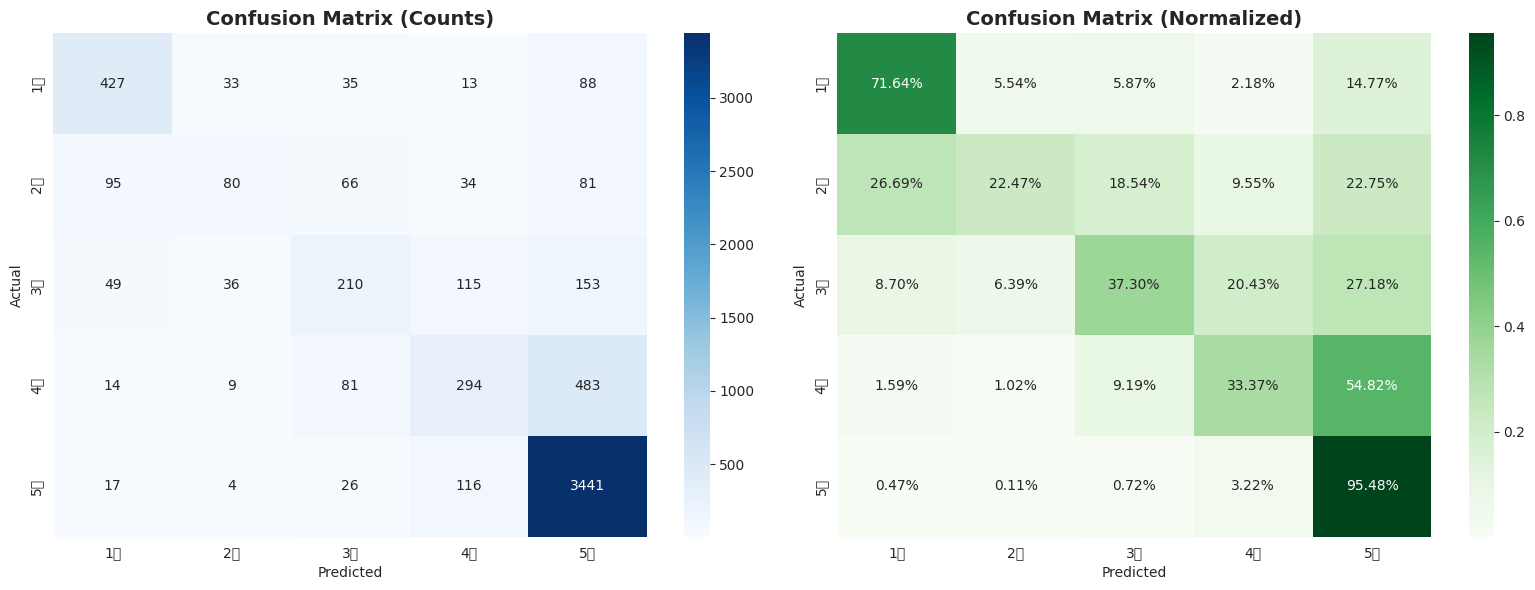

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
labels = sorted(y_true.unique())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'{l}⭐' for l in labels],
            yticklabels=[f'{l}⭐' for l in labels], ax=axes[0])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=[f'{l}⭐' for l in labels],
            yticklabels=[f'{l}⭐' for l in labels], ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# Off-by-N analysis

abs_diff = np.abs(y_true.values - y_pred.values)

off_by_0 = (abs_diff == 0).mean()
off_by_1 = (abs_diff <= 1).mean()
off_by_2 = (abs_diff <= 2).mean()

print(' Off-by-N Analysis:')
print(f'   Exact match (off by 0):     {off_by_0*100:.2f}%')
print(f'   Within 1 star (off by ≤1):  {off_by_1*100:.2f}%')
print(f'   Within 2 stars (off by ≤2): {off_by_2*100:.2f}%')

 Off-by-N Analysis:
   Exact match (off by 0):     74.20%
   Within 1 star (off by ≤1):  91.28%
   Within 2 stars (off by ≤2): 96.38%


## 9) Feature Importance

In [ ]:
# Feature importance
importance_df = predictor.feature_importance(test_df, silent=True)

print(' Top features:')
print(importance_df)

 Top features:
                          importance    stddev       p_value  n  p99_high  \
text                         0.12084  0.002747  3.204077e-08  5  0.126497   
title                        0.09184  0.005047  1.089675e-06  5  0.102231   
product_avg_rating           0.01532  0.000769  7.609050e-07  5  0.016904   
positive_word_count          0.00792  0.001254  7.291406e-05  5  0.010502   
negative_word_count          0.00168  0.000756  3.833847e-03  5  0.003237   
product_rating_count_log     0.00128  0.001221  3.955024e-02  5  0.003795   
verified_purchase_int        0.00096  0.001396  9.943341e-02  5  0.003834   
review_month                 0.00060  0.000316  6.617800e-03  5  0.001251   
product_price_log            0.00060  0.000447  1.997098e-02  5  0.001521   
review_year                  0.00052  0.000540  4.889333e-02  5  0.001633   
word_count                   0.00024  0.000477  1.619704e-01  5  0.001223   
uppercase_ratio              0.00020  0.000872  3.174951e-01 

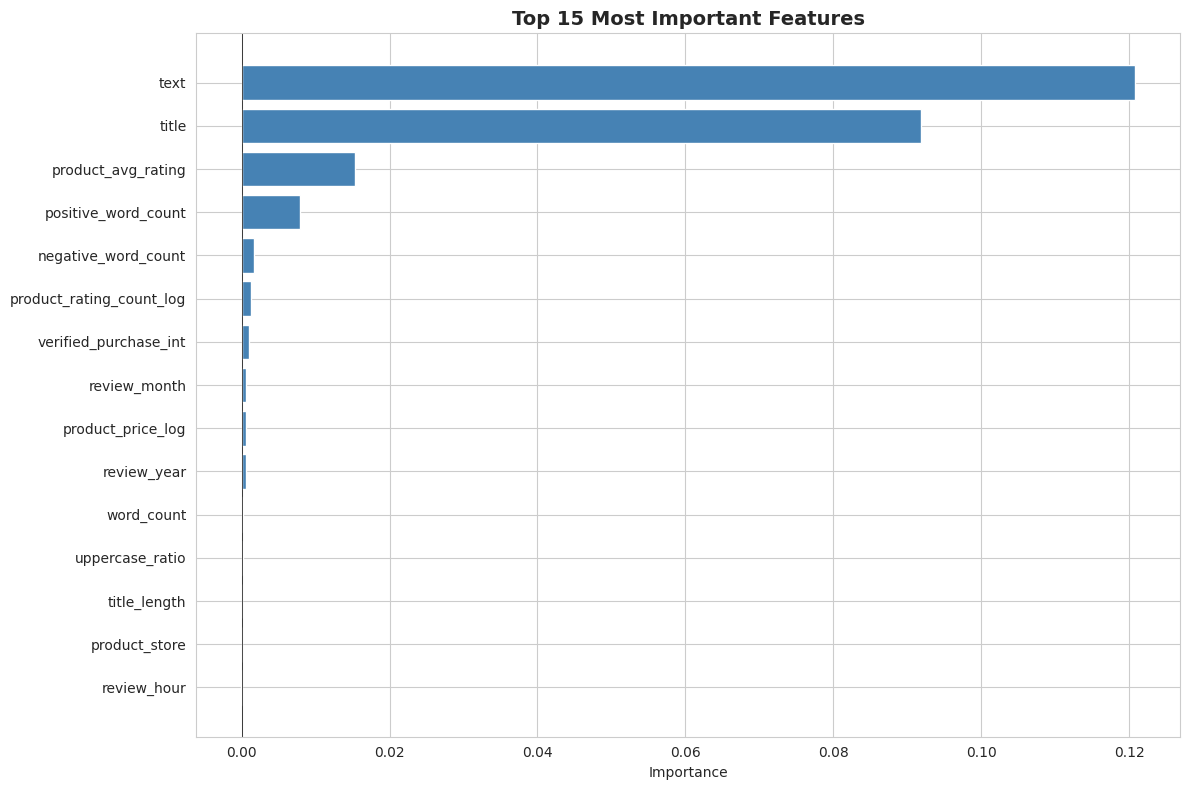

In [ ]:
#  Plot top 15 features
top_n = min(15, len(importance_df))
top_features = importance_df.head(top_n).iloc[::-1]

fig, ax = plt.subplots(figsize=(12, 8))
ax.barh(top_features.index, top_features['importance'], color='steelblue')
ax.set_title(f'Top {top_n} Most Important Features', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance')
ax.axvline(0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

## 10) Model Testing

In [ ]:
# Load the model (deployment simulation)
loaded_predictor = TabularPredictor.load(MODEL_PATH)

print(f' Model loaded from: {MODEL_PATH}')
print(f' Best model: {loaded_predictor.model_best}')

 Model loaded from: /content/models/autogluon_rating_predictor
 Best model: WeightedEnsemble_L2


In [ ]:
# Test with a positive review

sample_review = pd.DataFrame([{
    'title': 'Amazing product, highly recommend!',
    'text': 'I love this product so much. It works perfectly and the quality is excellent. Best purchase I have made this year. Will definitely buy again!',
    'text_length': 140,
    'title_length': 32,
    'word_count': 26,
    'exclamation_count': 2,
    'question_count': 0,
    'uppercase_ratio': 0.02,
    'positive_word_count': 4,
    'negative_word_count': 0,
    'review_year': 2023,
    'review_month': 6,
    'review_dayofweek': 3,
    'review_hour': 14,
    'verified_purchase_int': 1,
    'helpful_vote': 5,
    'has_image': 1,
    'product_avg_rating': 4.5,
    'product_rating_count_log': 5.0,
    'product_price_log': 3.0,
    'product_store': 'BeautyStore'
}])

pred = loaded_predictor.predict(sample_review)
proba = loaded_predictor.predict_proba(sample_review)

print(f' Predicted rating: {pred.iloc[0]} stars')

print(f'\n Class probabilities:')
for cls, p in proba.iloc[0].items():
    bar = '█' * int(p * 30)
    print(f'   {cls}⭐  {p:.3f}  {bar}')

 Predicted rating: 5 stars

 Class probabilities:
   1⭐  0.001  
   2⭐  0.000  
   3⭐  0.001  
   4⭐  0.003  
   5⭐  0.996  █████████████████████████████


## 11) Gradio



In [ ]:
import gradio as gr

POSITIVE_WORDS = ['love', 'great', 'excellent', 'amazing', 'perfect',
                  'best', 'wonderful', 'awesome', 'fantastic', 'recommend']
NEGATIVE_WORDS = ['bad', 'terrible', 'awful', 'worst', 'hate',
                  'horrible', 'disappointing', 'waste', 'broken', 'poor']

def count_words_helper(text, word_list):
    text_lower = text.lower()
    return sum(text_lower.count(w) for w in word_list)

def predict_rating(
    title, text, verified_purchase, helpful_vote, has_image,
    product_avg_rating, product_rating_count, product_price, product_store
):
    if not text or not text.strip():
        return ' Please enter review text', {f'{i}⭐': 0.0 for i in range(1, 6)}, ''

    title = title or ''
    now = pd.Timestamp.now()

    row = {
        'title': title,
        'text': text,
        'text_length': len(text),
        'title_length': len(title),
        'word_count': len(text.split()),
        'exclamation_count': text.count('!'),
        'question_count': text.count('?'),
        'uppercase_ratio': sum(1 for c in text if c.isupper()) / max(len(text), 1),
        'positive_word_count': count_words_helper(text, POSITIVE_WORDS),
        'negative_word_count': count_words_helper(text, NEGATIVE_WORDS),
        'review_year': now.year,
        'review_month': now.month,
        'review_dayofweek': now.dayofweek,
        'review_hour': now.hour,
        'verified_purchase_int': int(verified_purchase),
        'helpful_vote': int(helpful_vote),
        'has_image': int(has_image),
        'product_avg_rating': float(product_avg_rating),
        'product_rating_count_log': float(np.log1p(product_rating_count)),
        'product_price_log': float(np.log1p(product_price)),
        'product_store': product_store or 'Unknown',
    }

    df_input = pd.DataFrame([row])

    pred = loaded_predictor.predict(df_input).iloc[0]
    proba = loaded_predictor.predict_proba(df_input).iloc[0]

    stars_visual = '⭐' * int(pred) + '☆' * (5 - int(pred))
    main_output = f'###  Predicted Rating: **{pred} stars**\n\n# {stars_visual}'

    proba_dict = {f'{int(cls)}⭐': float(p) for cls, p in proba.items()}

    confidence = proba.max() * 100
    confidence_text = (
        f'**Confidence:** {confidence:.1f}%\n\n'
        f'**Most likely:** {proba.idxmax()} stars ({proba.max()*100:.1f}%)\n\n'
        f'**Second most likely:** {proba.nlargest(2).index[-1]} stars ({proba.nlargest(2).iloc[-1]*100:.1f}%)'
    )

    return main_output, proba_dict, confidence_text


EXAMPLES = [
    ['Amazing product!', 'I love this product. It works perfectly. Best purchase ever!',
     True, 5, True, 4.5, 150, 25.99, 'BeautyStore'],
    ['Terrible quality', 'This product is awful. Worst purchase. Broken on arrival. Total waste of money.',
     True, 8, False, 3.0, 50, 12.50, 'GenericStore'],
    ['Decent product', 'It works okay. Nothing special but no complaints either.',
     True, 1, False, 4.0, 100, 15.99, 'OkayStore'],
]

with gr.Blocks(title='Amazon Reviews Rating Predictor', theme=gr.themes.Soft()) as demo:
    gr.Markdown('#  Amazon Reviews Rating Predictor')
    gr.Markdown('### Predict star ratings (1–5) for Amazon Beauty products\n\nPowered by **AutoGluon** and trained on **Amazon Reviews 2023** dataset')

    with gr.Row():
        with gr.Column(scale=2):
            gr.Markdown('###  Review Information')
            title_in = gr.Textbox(label='Review Title', placeholder='Example: Amazing product!')
            text_in = gr.Textbox(label='Review Text *', placeholder='Write your review here...', lines=6)

            with gr.Row():
                verified_in = gr.Checkbox(label='Verified Purchase', value=True)
                image_in = gr.Checkbox(label='Has Image(s)', value=False)

            helpful_in = gr.Slider(label='Helpful Votes', minimum=0, maximum=100, value=0, step=1)

            gr.Markdown('###  Product Information')
            with gr.Row():
                avg_rating_in = gr.Slider(label='Product Avg Rating', minimum=1.0, maximum=5.0, value=4.0, step=0.1)
                count_in = gr.Number(label='Total Ratings', value=100, precision=0)

            with gr.Row():
                price_in = gr.Number(label='Price (USD)', value=15.0)
                store_in = gr.Textbox(label='Store', value='Unknown')

            btn = gr.Button(' Predict Rating', variant='primary', size='lg')

        with gr.Column(scale=1):
            gr.Markdown('###  Result')
            out_main = gr.Markdown()
            out_proba = gr.Label(num_top_classes=5)
            out_conf = gr.Markdown()

    btn.click(
        fn=predict_rating,
        inputs=[title_in, text_in, verified_in, helpful_in, image_in,
                avg_rating_in, count_in, price_in, store_in],
        outputs=[out_main, out_proba, out_conf]
    )

    gr.Markdown('###  Try these examples:')
    gr.Examples(
        examples=EXAMPLES,
        inputs=[title_in, text_in, verified_in, helpful_in, image_in,
                avg_rating_in, count_in, price_in, store_in],
    )

demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d800b2cc2bcf71ab26.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)




###  لحفظ النموذج على Google Drive (اختياري)



```python
from google.colab import drive
drive.mount('/content/drive')

import shutil
shutil.copytree('/content/models', '/content/drive/MyDrive/amazon_ml_models')
print(' تم حفظ النموذج على Google Drive')
```

